### trait prompt 人格提示词
- ref: Jia Deng, Tianyi Tang, Yanbin Yin, Wenhao Yang, Wayne Xin Zhao, Ji-Rong Wen. Neuron-based Personality Trait Induction in Large Language Models. ICLR 2025.

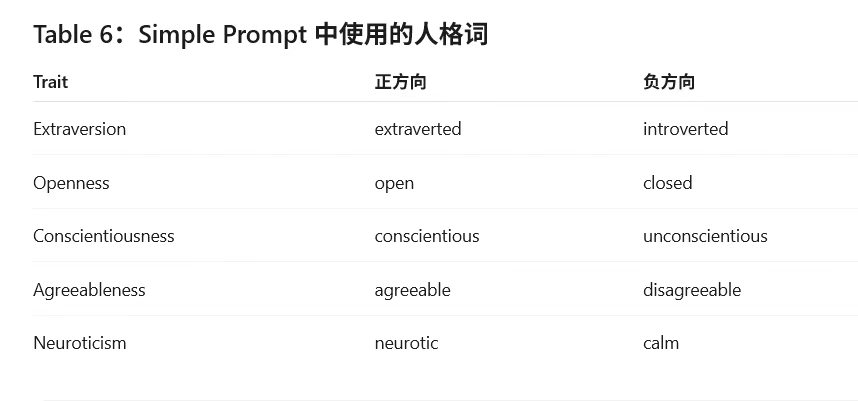

In [ ]:
import transformers, accelerate, torch
path = '/mnt/nvme2/models/amadeus/model_zoo/qwen3-4b-instruct-2507'
model = transformers.AutoModelForCausalLM.from_pretrained(path, 
                                                          trust_remote_code=True,
                                                          device_map='auto',
                                                          torch_dtype=torch.float16,   
                                                          ignore_mismatched_sizes=True)

In [ ]:
from datasets import *
numina = load_dataset('/mnt/nvme2/models/amadeus/dataset_zoo/NuminaMath-CoT')


In [ ]:
big5_dataset['train'][20268]

In [ ]:
from transformers import *
import torch
model_pth = '/mnt/nvme2/models/amadeus/cpvm_output/merged_model/qwen3-4b-instruct-2507-lora-big5chat-conscientiousness-high-ep20-merged'
model = AutoModelForCausalLM.from_pretrained(
    model_pth, 
    trust_remote_code=True, 
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto"
    ).eval()
tokenizer = AutoTokenizer.from_pretrained(model_pth, trust_remote_code=True)

In [ ]:
text = 'what do you think your personality is?'
inputs = tokenizer(text, return_tensors="pt").to(model.device)
outputs_idx = model.generate(**inputs, max_length=1024)
outputs = tokenizer.decode(outputs_idx[0], skip_special_tokens=True)
print(outputs)

### 双级不对称测试 （bipolar asymmetry）
令 $\Delta_H=\theta_H-\theta_B$、$\Delta_L=\theta_L-\theta_B$。下面分开检验两个命题：

- **方向完全反向**：存在 $c>0$ 使 $\Delta_H=-c\Delta_L$，此时 cosine = -1、反向夹角 = 0°。
- **以 base 为中点的完全对称**：$\Delta_H=-\Delta_L$，还要求两边范数相等且中点误差 = 0。
- **参数支持不对称**：比较 non-zero support Jaccard、共同支持中的异号率和同向点积质量。

> 代码直接分块读取 safetensors，不会同时加载三份 4B 模型。建议重启 kernel 后只运行本节，避免前面 cell 的模型继续占用显存。层 bootstrap 只是不确定性的结构性描述；正式归因还需要 high/low 匹配训练步数、token、超参与 seed。


In [ ]:
# Model paths for one matched trait (change these three paths for another trait).
base_model_pth = '/mnt/nvme2/models/amadeus/model_zoo/qwen3-4b-instruct-2507'
high_model_pth = '/mnt/nvme2/models/amadeus/cpvm_output/sft/full/qwen3-4b-instruct-2507-sft-full-big5chat-Extraversion-high-ep10/checkpoint-1000'
low_model_pth = '/mnt/nvme2/models/amadeus/cpvm_output/sft/full/qwen3-4b-instruct-2507-sft-full-big5chat-Extraversion-low-ep5/checkpoint-800'

In [ ]:
import warnings
import gc
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import torch
from IPython.display import display

try:
    from CPVM.code.bipolar_asymmetry import (
        analyze_bipolar_asymmetry, bootstrap_transformer_layers,
        build_result_tables, training_progress_table,
    )
except ModuleNotFoundError as error:
    if error.name != 'CPVM':
        raise
    candidates = [
        Path.cwd() / 'CPVM' / 'code', Path.cwd() / 'code', Path.cwd(),
        Path('/home/wbw/workspace/CPVM/code'),
    ]
    helper_dir = next((path for path in candidates if (path / 'bipolar_asymmetry.py').exists()), None)
    if helper_dir is None:
        raise ModuleNotFoundError('Cannot locate CPVM/code/bipolar_asymmetry.py') from error
    sys.path.insert(0, str(helper_dir))
    from bipolar_asymmetry import (
        analyze_bipolar_asymmetry, bootstrap_transformer_layers,
        build_result_tables, training_progress_table,
    )

# ACTIVE_EPSILON only affects support/sign metrics; geometry always uses all weights.
# For BF16 checkpoints, 0.0 means an exact stored-value support comparison.
ACTIVE_EPSILON = 0.0
CHUNK_NUMEL = 2_000_000       # about tens of MB of temporary CPU memory
N_BOOTSTRAP = 5_000
SEED = 20260824
NUMERICAL_COSINE_TOL = 1e-6   # tolerance for the exact cos = -1 condition
PRACTICAL_ANGLE_DEG = 5.0     # configurable practical opposition tolerance

# Release model objects left by earlier notebook cells; this experiment streams weights.
for model_variable in ('model', 'base_model', 'high_model', 'low_model'):
    globals().pop(model_variable, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1. Check whether high/low have a comparable optimization budget.
training_progress = training_progress_table(high_model_pth, low_model_pth)
display(training_progress)
if training_progress['global_step'].dropna().nunique() > 1:
    warnings.warn(
        'High and low checkpoints have different training steps. The result can '
        'establish asymmetry for this checkpoint pair, but cannot attribute it '
        'solely to personality polarity. Use matched steps/tokens/hyperparameters/seeds.'
    )

# 2. Stream all common parameters and accumulate float64 sufficient statistics.
analysis_result = analyze_bipolar_asymmetry(
    base_model_pth,
    high_model_pth,
    low_model_pth,
    chunk_numel=CHUNK_NUMEL,
    active_epsilon=ACTIVE_EPSILON,
    show_progress=True,
)
print(f"Compared {analysis_result['compared_key_count']} physical weight tensors.")
print(f"Ignored tied/duplicate keys: {analysis_result['ignored_keys']}")

# 3. Global, layer, module and per-tensor effect sizes.
summary_df, layer_df, module_df, tensor_df = build_result_tables(analysis_result)
display(summary_df.round({'观测值': 8}))

view_columns = [
    'group', 'cosine', 'anti_angle_deg', 'direction_asymmetry',
    'midpoint_error', 'high_low_norm_ratio', 'support_jaccard',
    'opposite_sign_rate', 'positive_dot_mass_ratio',
]
print('Per-layer results:')
display(layer_df[view_columns].round(6))
print('Per-module-family results:')
display(module_df[view_columns].round(6))
# tensor_df contains all per-parameter results for later drilling down.

# 4. Bootstrap the 36 blocks while keeping embedding/final norm fixed.
bootstrap_ci = bootstrap_transformer_layers(
    analysis_result['layer_raw'], n_bootstrap=N_BOOTSTRAP, seed=SEED
)
display(bootstrap_ci.round(8))

# 5. Report exact-condition failure and the separate practical 5-degree criterion.
metrics = analysis_result['global_metrics']
angle_ci = bootstrap_ci.set_index('metric').loc['anti_angle_deg']
print(f"Global cosine = {metrics['cosine']:.8f}; distance from -1 = {metrics['opposition_gap']:.8f}")
print(f"Global angle to exact opposition = {metrics['anti_angle_deg']:.4f}°")
if metrics['opposition_gap'] > NUMERICAL_COSINE_TOL:
    print('Exact-direction result: Δhigh and Δlow are not numerically antiparallel.')
else:
    print('Exact-direction result: indistinguishable from antiparallel at the chosen numerical tolerance.')
print(
    f"Global angle 95% structural CI (block bootstrap): "
    f"[{angle_ci['ci_2.5%']:.4f}°, {angle_ci['ci_97.5%']:.4f}°]"
)
if angle_ci['ci_2.5%'] > PRACTICAL_ANGLE_DEG:
    print('Conclusion: supports practically meaningful directional bipolar asymmetry.')
elif metrics['anti_angle_deg'] > PRACTICAL_ANGLE_DEG:
    print('Conclusion: the point estimate is asymmetric, but the layer-bootstrap CI crosses the practical threshold.')
else:
    print('Conclusion: this pair does not exceed the pre-registered practical directional threshold.')

if metrics['midpoint_error'] > 1e-3:
    print('The base model is also not the exact midpoint of high and low (magnitude/full-symmetry failure).')
print('Caveat: layer bootstrap is descriptive; repeat matched checkpoint pairs across seeds for population-level inference.')

### 参数贡献度统计

> 该单元只在 CPU 上分块读取贡献文件，不会加载模型。前两张分布图用于观察中心形状与数量级；新增的第三张图使用全部标量、原始贡献值、等宽 bins 和原始频数，不做采样、裁剪、对数或对称变换。通过 pi_contribution_channel 选择 L_plus、L_star 或 L_contrast；其中 L_contrast 按元素计算 L_plus + L_star。建议重启 kernel 后单独运行本节。

累计 Top-k 贡献曲线移至本节最后一个独立绘图单元：提供可横向滚动的长图，以及原点附近 0–1% 和 0–0.1% 的局部视图。统计完成后，仅重新运行绘图单元即可调整宽度或放大范围；曲线仍使用已有的全量分箱累加结果。


In [ ]:
from contextlib import ExitStack
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from safetensors import safe_open as pi_safe_open
from tqdm.auto import tqdm
from CPVM.code.topk_merge import discover_contribution_files


pi_contribution_dir = Path('/mnt/nvme2/models/amadeus/cpvm_output/path_integral/qwen3-4b-instruct-2507-sft-full-big5chat-Extraversion-high-ep10-checkpoint-1000')
pi_contribution_files = discover_contribution_files(pi_contribution_dir)
pi_l_plus_path = pi_contribution_files['L_plus']
pi_l_star_path = pi_contribution_files['L_star']
pi_contribution_channel = 'L_plus'  # L_plus | L_star | L_contrast
pi_contribution_paths = {
    'L_plus': [pi_l_plus_path],
    'L_star': [pi_l_star_path],
    'L_contrast': [pi_l_plus_path, pi_l_star_path],
}[pi_contribution_channel]
pi_channel_label = {
    'L_plus': 'L_plus',
    'L_star': 'L_star',
    'L_contrast': 'L_contrast (L_plus + L_star)',
}[pi_contribution_channel]
pi_chunk_numel = 5_000_000
pi_sample_stride = 2_048
pi_histogram_bins = 200
pi_concentration_bins = 8_192
pi_layer_pattern = re.compile(r'^model\.layers\.(\d+)\.')


def pi_parameter_layer(parameter_name):
    """Map a parameter name to a transformer layer or global block."""

    match = pi_layer_pattern.match(parameter_name)
    if match:
        return f'layer_{int(match.group(1)):02d}'
    if parameter_name.startswith('model.embed_tokens.'):
        return 'embedding'
    if parameter_name.startswith('model.norm.'):
        return 'final_norm'
    if parameter_name.startswith('lm_head.'):
        return 'lm_head'
    return 'other'


def pi_parameter_module(parameter_name):
    """Map a Qwen parameter name to its functional module."""

    if parameter_name.startswith('model.embed_tokens.'):
        return 'embedding'
    if parameter_name.startswith('model.norm.'):
        return 'norm/final'
    if parameter_name.startswith('lm_head.'):
        return 'lm_head'
    if '.self_attn.' in parameter_name:
        component = parameter_name.split('.self_attn.', 1)[1].split('.', 1)[0]
        return f'attention/{component}'
    if '.mlp.' in parameter_name:
        component = parameter_name.split('.mlp.', 1)[1].split('.', 1)[0]
        return f'mlp/{component}'
    if '.input_layernorm.' in parameter_name:
        return 'norm/input_layernorm'
    if '.post_attention_layernorm.' in parameter_name:
        return 'norm/post_attention_layernorm'
    return 'other'


def pi_iter_tensor_chunks(handle, parameter_name):
    """Yield bounded CPU chunks from one safetensors parameter."""

    tensor_slice = handle.get_slice(parameter_name)
    tensor_shape = tuple(tensor_slice.get_shape())
    row_width = int(np.prod(tensor_shape[1:])) if len(tensor_shape) > 1 else 1
    rows_per_chunk = max(1, pi_chunk_numel // row_width)
    for row_start in range(0, tensor_shape[0], rows_per_chunk):
        yield tensor_slice[row_start:row_start + rows_per_chunk].reshape(-1).float()


def pi_iter_contribution_chunks(handles, parameter_name):
    """Yield one channel chunk, or add L_plus and L_star chunk by chunk."""

    chunk_iterators = [pi_iter_tensor_chunks(handle, parameter_name) for handle in handles]
    for chunks in zip(*chunk_iterators):
        combined_chunk = chunks[0].clone()
        for chunk in chunks[1:]:
            combined_chunk.add_(chunk)
        yield combined_chunk


def pi_scan_contributions(contribution_paths):
    """Scan every scalar for exact parameter statistics and the global range."""

    parameter_rows = []
    sample_parts = []
    global_min = float('inf')
    global_max = float('-inf')
    with ExitStack() as stack:
        handles = [
            stack.enter_context(pi_safe_open(str(path), framework='pt', device='cpu'))
            for path in contribution_paths
        ]
        for parameter_name in tqdm(handles[0].keys(), desc=f'Scanning {pi_channel_label}'):
            parameter_numel = int(np.prod(handles[0].get_slice(parameter_name).get_shape()))
            signed_sum = 0.0
            positive_sum = 0.0
            negative_sum = 0.0
            nonzero_numel = 0

            for chunk in pi_iter_contribution_chunks(handles, parameter_name):
                signed_sum += chunk.sum(dtype=torch.float64).item()
                positive_sum += chunk.clamp_min(0).sum(dtype=torch.float64).item()
                negative_sum += chunk.clamp_max(0).sum(dtype=torch.float64).item()
                nonzero_numel += torch.count_nonzero(chunk).item()
                chunk_min, chunk_max = torch.aminmax(chunk)
                global_min = min(global_min, chunk_min.item())
                global_max = max(global_max, chunk_max.item())
                sample_parts.append(chunk[::pi_sample_stride].numpy().copy())

            parameter_rows.append({
                'parameter': parameter_name,
                'layer': pi_parameter_layer(parameter_name),
                'module': pi_parameter_module(parameter_name),
                'numel': parameter_numel,
                'nonzero_numel': nonzero_numel,
                'signed_sum': signed_sum,
                'positive_sum': positive_sum,
                'negative_sum': negative_sum,
            })
    parameter_df = pd.DataFrame(parameter_rows)
    contribution_sample = np.concatenate(sample_parts)
    return parameter_df, global_min, global_max, contribution_sample


def pi_scan_histograms(contribution_paths, raw_bin_edges, ranked_bin_edges):
    """Build the raw histogram and signed-ranking histogram from all parameters."""

    raw_counts = np.zeros(len(raw_bin_edges) - 1, dtype=np.int64)
    ranked_counts = np.zeros(len(ranked_bin_edges) - 1, dtype=np.int64)
    ranked_sums = np.zeros(len(ranked_bin_edges) - 1, dtype=np.float64)
    with ExitStack() as stack:
        handles = [
            stack.enter_context(pi_safe_open(str(path), framework='pt', device='cpu'))
            for path in contribution_paths
        ]
        for parameter_name in tqdm(handles[0].keys(), desc=f'Building {pi_channel_label} histograms'):
            for chunk in pi_iter_contribution_chunks(handles, parameter_name):
                values = chunk.numpy()
                raw_counts += np.histogram(values, bins=raw_bin_edges)[0]
                bin_indices = np.searchsorted(
                    ranked_bin_edges, values, side='right'
                ) - 1
                np.minimum(bin_indices, len(ranked_counts) - 1, out=bin_indices)
                ranked_counts += np.bincount(
                    bin_indices, minlength=len(ranked_counts)
                )
                ranked_sums += np.bincount(
                    bin_indices,
                    weights=values.astype(np.float64, copy=False),
                    minlength=len(ranked_sums),
                )
    return raw_counts, ranked_counts, ranked_sums


def pi_aggregate(parameter_df, group_column):
    """Aggregate signed, positive, and negative contributions by one grouping."""

    grouped = (
        parameter_df.groupby(group_column, as_index=False)
        .agg(
            parameter_blocks=('parameter', 'count'),
            numel=('numel', 'sum'),
            nonzero_numel=('nonzero_numel', 'sum'),
            signed_sum=('signed_sum', 'sum'),
            positive_sum=('positive_sum', 'sum'),
            negative_sum=('negative_sum', 'sum'),
        )
    )
    grouped['mean_signed'] = grouped['signed_sum'] / grouped['numel']
    grouped['mean_positive'] = grouped['positive_sum'] / grouped['numel']
    grouped['nonzero_pct'] = 100 * grouped['nonzero_numel'] / grouped['numel']
    grouped['positive_share_pct'] = 100 * grouped['positive_sum'] / grouped['positive_sum'].sum()
    return grouped


def pi_layer_sort_key(layer_name):
    """Sort embedding, numbered transformer layers, and final blocks naturally."""

    if layer_name == 'embedding':
        return -1
    if layer_name.startswith('layer_'):
        return int(layer_name.split('_')[1])
    if layer_name == 'final_norm':
        return 1_000
    if layer_name == 'lm_head':
        return 1_001
    return 2_000


pi_parameter_df, pi_global_min, pi_global_max, pi_contribution_sample = (
    pi_scan_contributions(pi_contribution_paths)
)
pi_layer_df = pi_aggregate(pi_parameter_df, 'layer')
pi_layer_df['sort_key'] = pi_layer_df['layer'].map(pi_layer_sort_key)
pi_layer_df = pi_layer_df.sort_values('sort_key').drop(columns='sort_key').reset_index(drop=True)
pi_module_df = (
    pi_aggregate(pi_parameter_df, 'module')
    .sort_values('positive_sum', ascending=False)
    .reset_index(drop=True)
)
pi_histogram_edges = np.linspace(
    pi_global_min, pi_global_max, pi_histogram_bins + 1, dtype=np.float64
)
pi_half_concentration_bins = pi_concentration_bins // 2
pi_ranked_edges = np.r_[
    -np.geomspace(
        abs(pi_global_min), np.finfo(np.float32).tiny, pi_half_concentration_bins
    ),
    0.0,
    np.geomspace(
        np.finfo(np.float32).tiny, pi_global_max, pi_half_concentration_bins
    ),
]
pi_histogram_counts, pi_ranked_counts, pi_ranked_sums = pi_scan_histograms(
    pi_contribution_paths, pi_histogram_edges, pi_ranked_edges
)

pi_total_numel = int(pi_parameter_df['numel'].sum())
pi_total_nonzero = int(pi_parameter_df['nonzero_numel'].sum())
pi_ranked_nonempty = pi_ranked_counts[::-1] > 0
pi_descending_counts = pi_ranked_counts[::-1][pi_ranked_nonempty]
pi_descending_sums = pi_ranked_sums[::-1][pi_ranked_nonempty]
pi_total_signed = pi_descending_sums.sum()
pi_top_parameter_pct = 100 * np.r_[0, np.cumsum(pi_descending_counts)] / pi_total_numel
pi_cumulative_signed_ratio = np.r_[0, np.cumsum(pi_descending_sums)] / pi_total_signed
print(f'Contribution channel: {pi_channel_label}')
print('Files: ' + ', '.join(path.name for path in pi_contribution_paths))
print(f'Parameter blocks: {len(pi_parameter_df):,}')
print(f'Scalar parameters: {pi_total_numel:,}')
print(f'Exact-zero fraction: {1 - pi_total_nonzero / pi_total_numel:.4%}')
print(f'Raw contribution range: [{pi_global_min:.8e}, {pi_global_max:.8e}]')
print(f'Histogram parameters counted: {int(pi_histogram_counts.sum()):,}')
print(f'Total signed contribution: {pi_total_signed:.8e}')
print(f'Total positive contribution: {pi_parameter_df["positive_sum"].sum():.8e}')
print(f'Total negative contribution: {pi_parameter_df["negative_sum"].sum():.8e}')

pi_table_columns = [
    'parameter_blocks', 'numel', 'nonzero_pct', 'signed_sum', 'positive_sum',
    'negative_sum', 'mean_signed', 'mean_positive', 'positive_share_pct',
]
print(f'{pi_channel_label} layer statistics')
display(pi_layer_df.set_index('layer')[pi_table_columns])
print(f'{pi_channel_label} module statistics')
display(pi_module_df.set_index('module')[pi_table_columns])

# Keep the two detailed distribution views for the dense center and long tail.
pi_nonzero_sample = pi_contribution_sample[pi_contribution_sample != 0]
pi_clip = np.quantile(np.abs(pi_nonzero_sample), 0.999)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(
    np.clip(pi_nonzero_sample, -pi_clip, pi_clip),
    bins=160,
    color='#4472C4',
    alpha=0.85,
)
axes[0].set_yscale('log')
axes[0].set_title(f'Signed {pi_channel_label} distribution (clipped at 99.9% |A|)')
axes[0].set_xlabel('Parameter contribution')
axes[0].set_ylabel('Sample count (log scale)')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[1].hist(np.log10(np.abs(pi_nonzero_sample)), bins=160, color='#ED7D31', alpha=0.85)
axes[1].set_title(f'Non-zero {pi_channel_label} contribution magnitude')
axes[1].set_xlabel('log10(|parameter contribution|)')
axes[1].set_ylabel('Sample count')
fig.suptitle(f'CPVM {pi_channel_label} detailed contribution distributions')
fig.tight_layout()
plt.show()

# Plot the ordinary full-data histogram with raw axes and no clipping.
fig, ax = plt.subplots(figsize=(12, 5))
ax.stairs(pi_histogram_counts, pi_histogram_edges, fill=True, color='#4472C4', alpha=0.85)
ax.set_title(f'CPVM {pi_channel_label} parameter-level distribution (all parameters)')
ax.set_xlabel('Raw parameter contribution')
ax.set_ylabel('Number of parameters')
ax.axvline(0, color='black', linewidth=0.8)
fig.tight_layout()
plt.show()

# The cumulative Top-k curve is drawn in the next cell for quick replotting.

# Plot net direction and positive attribution share for every layer.
pi_layer_colors = np.where(pi_layer_df['signed_sum'] >= 0, '#4C9F70', '#C44E52')
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].bar(pi_layer_df['layer'], pi_layer_df['signed_sum'], color=pi_layer_colors)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Signed contribution sum')
axes[0].set_title(f'Net {pi_channel_label} contribution by layer')
axes[1].bar(pi_layer_df['layer'], pi_layer_df['positive_share_pct'], color='#4472C4')
axes[1].set_ylabel('Share of total positive contribution (%)')
axes[1].set_title(f'Positive {pi_channel_label} attribution by layer')
axes[1].tick_params(axis='x', rotation=65)
fig.tight_layout()
plt.show()

# Plot the same two views for functional modules such as q_proj and gate_proj.
pi_module_plot_df = pi_module_df.sort_values('positive_sum', ascending=True)
pi_module_colors = np.where(pi_module_plot_df['signed_sum'] >= 0, '#4C9F70', '#C44E52')
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
axes[0].barh(pi_module_plot_df['module'], pi_module_plot_df['signed_sum'], color=pi_module_colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Signed contribution sum')
axes[0].set_title(f'Net {pi_channel_label} contribution by module')
axes[1].barh(pi_module_plot_df['module'], pi_module_plot_df['positive_share_pct'], color='#ED7D31')
axes[1].set_xlabel('Share of total positive contribution (%)')
axes[1].set_title(f'Positive {pi_channel_label} attribution by module')
fig.tight_layout()
plt.show()

In [ ]:
# Long cumulative-contribution views; rerun only this cell after statistics.
# Change the zoom limits to inspect an even smaller neighborhood of the origin.
from base64 import b64encode
from io import BytesIO

from IPython.display import HTML, display
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, PercentFormatter

pi_concentration_width_inches = 30
pi_concentration_height_per_view = 5
pi_concentration_dpi = 120
pi_concentration_views_pct = (100.0, 1.0, 0.1)

fig, axes = plt.subplots(
    len(pi_concentration_views_pct), 1,
    figsize=(
        pi_concentration_width_inches,
        pi_concentration_height_per_view * len(pi_concentration_views_pct),
    ),
    dpi=pi_concentration_dpi,
    squeeze=False,
)
for ax, xmax in zip(axes[:, 0], pi_concentration_views_pct):
    # Clip to this window and interpolate only its right boundary. This also
    # gives each zoom its own y range instead of retaining the global peak.
    visible = pi_top_parameter_pct < xmax
    view_x = np.r_[pi_top_parameter_pct[visible], xmax]
    view_y = np.r_[
        pi_cumulative_signed_ratio[visible],
        np.interp(xmax, pi_top_parameter_pct, pi_cumulative_signed_ratio),
    ]
    ax.plot(
        view_x, view_y,
        color='#C44E52', linewidth=2.2,
        marker='.' if xmax < 100 else None, markersize=3,
        label=f'Parameters ranked by signed {pi_channel_label} contribution',
    )
    ax.plot(
        [0, xmax], [0, xmax / 100], '--', color='gray', linewidth=1,
        label='Uniform contribution',
    )
    ax.axhline(1, color='black', linestyle=':', linewidth=1, label='Net total')
    ax.set_xlim(0, xmax)
    ymin = min(0.0, float(view_y.min()))
    ymax = max(xmax / 100, float(view_y.max()))
    padding = max(ymax - ymin, 1e-12) * 0.05
    ax.set_ylim(ymin - padding if ymin < 0 else 0, ymax + padding)
    ax.set_xlabel('Top parameters (%)')
    ax.set_ylabel('Cumulative signed contribution / net total')
    view_label = 'all parameters' if xmax == 100 else 'near-origin zoom'
    ax.set_title(
        f'Signed {pi_channel_label} contribution concentration '
        f'({view_label}, top 0–{xmax:g}%)'
    )
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.grid(which='major', alpha=0.3)
    ax.grid(which='minor', axis='x', alpha=0.12)
    ax.legend(loc='upper right')
fig.tight_layout(h_pad=3)

# Keep the actual 3600-pixel width: notebook frontends otherwise shrink a
# wide figure to the cell width, making the early curve and labels tiny.
with BytesIO() as image_buffer:
    fig.savefig(image_buffer, format='png', dpi=pi_concentration_dpi)
    image_base64 = b64encode(image_buffer.getvalue()).decode('ascii')
image_width = round(pi_concentration_width_inches * pi_concentration_dpi)
plt.close(fig)
display(HTML(
    '<div style="max-width:100%; overflow-x:auto;">'
    f'<img src="data:image/png;base64,{image_base64}" '
    f'style="width:{image_width}px; max-width:none;" '
    'alt="Cumulative signed contribution: full range and near-origin zooms">'
    '</div>'
))
